In [1]:
import pandas as pd
df = pd.read_csv("report_brief_digest.csv")

In [2]:
df = df[(df['tag'].isna()) | (df['tag'] == 'cold')]

In [28]:
df['trace_name'].unique()

array(['meta_202210_kv', 'meta_202401_kv', 'twitter_cluster17',
       'twitter_cluster18', 'twitter_cluster24', 'twitter_cluster29',
       'twitter_cluster44', 'twitter_cluster45', 'twitter_cluster49',
       'twitter_cluster50', 'twitter_cluster52', 'twitter_cluster53'],
      dtype=object)

In [31]:
df[(df['wsr'] == 0.1) & (df['trace_name'] == 'meta_202210_kv') & (df['allocator'] == 'LRU') &
   (df['rebalance_strategy'].isin(['hits', 'marginal-hits', 'marginal-hits-tuned', 'disabled', 'tail-age', 'lama']))]\
      [['rebalance_strategy', 'miss_ratio', 'n_rebalanced_slabs', 'uuid']]

,rebalance_strategy,miss_ratio,n_rebalanced_slabs,uuid
76,hits,0.032896,1774,meta_202210_kv_traces_all_sort-c6efa2d473a1922...
77,marginal-hits-tuned,0.033273,940,meta_202210_kv_traces_all_sort-5123d7559d49bdd...
79,marginal-hits,0.041016,27941,meta_202210_kv_traces_all_sort-51116b22f1559ea...
80,disabled,0.053112,0,meta_202210_kv_traces_all_sort-2d208cf20223cbc...
81,tail-age,0.053554,7360,meta_202210_kv_traces_all_sort-b9948ea896309ae...
82,lama,0.053112,0,meta_202210_kv-25656eccfdac183fee9c022ccb13ddbc


In [5]:
df[(df['rebalance_strategy'] == 'tail-age') & (
    df['miss_ratio_reduction_from_disabled'] < 0
) & (df['allocator'] == 'LRU')].sort_values(by='miss_ratio_reduction_from_disabled')[['trace_name', 'wsr', 'allocator', 'miss_ratio_reduction_from_disabled', 'miss_ratio', 'n_rebalanced_slabs', 'uuid']]

,trace_name,wsr,allocator,miss_ratio_reduction_from_disabled,miss_ratio,n_rebalanced_slabs,uuid
762,twitter_cluster52,0.002,LRU,-0.003618,0.210394,1,twitter_cluster52-2ccf855556a7c91108d5794851b8...
497,twitter_cluster45,0.010,LRU,-0.002735,0.449115,17,twitter_cluster45-9d65d7c75afec844158fb89e59c3...
231,twitter_cluster18,0.050,LRU,-0.002547,0.077783,2,twitter_cluster18-1e8114576a8014f5ca0916071385...
890,twitter_cluster53,0.010,LRU,-0.001810,0.313274,1,twitter_cluster53-90dd11dd7ce61107ebb62185bd19...
119,meta_202401_kv,0.010,LRU,-0.001582,0.155271,978,meta_202401_kv_traces_all_sort-584fd267a09bfec...
392,twitter_cluster29,0.050,LRU,-0.000526,0.056233,1416,twitter_cluster29-af9414bd8d98cb0c69d9df85a081...
81,meta_202210_kv,0.100,LRU,-0.000442,0.053554,7360,meta_202210_kv_traces_all_sort-b9948ea896309ae...
211,twitter_cluster17,0.100,LRU,-0.000413,0.016855,11,twitter_cluster17-b78f16e7ab0d91779a509c13733a...
194,twitter_cluster17,0.050,LRU,-0.000373,0.028190,5,twitter_cluster17-3fc0366ca6414743f7c64717c580...
410,twitter_cluster29,0.100,LRU,-0.000273,0.047769,1994,twitter_cluster29-ccc730fce3d4a157c3963b943484...


In [3]:
df['trace_name'].unique()

array(['meta_202210_kv', 'meta_202401_kv', 'twitter_cluster17',
       'twitter_cluster18', 'twitter_cluster24', 'twitter_cluster29',
       'twitter_cluster44', 'twitter_cluster45', 'twitter_cluster49',
       'twitter_cluster50', 'twitter_cluster52', 'twitter_cluster53'],
      dtype=object)

In [3]:
trace_name = 'twitter_cluster11'
wsr = 0.01
df[(df['trace_name'] == trace_name) & (df['wsr'] == wsr)].sort_values(by='miss_ratio')\
    [['rebalance_strategy', 'allocator', 'tag', 'miss_ratio', 'throughput','n_rebalanced_slabs', 'miss_ratio_reduction_from_disabled', 'uuid']]

,rebalance_strategy,allocator,tag,miss_ratio,throughput,n_rebalanced_slabs,miss_ratio_reduction_from_disabled,uuid


In [3]:
import plotly.express as px

def plot_trace_wsr_line_even_x(
    df,
    trace_name,
    y="miss_ratio",
    x="wsr",
    color="rebalance_strategy",
    symbol="allocator",
    title=None
):
    plot_df = df[df["trace_name"] == trace_name].copy()
    if plot_df.empty:
        print(f"No data for trace_name: {trace_name}")
        return

    # Convert wsr to string and set as categorical for even spacing
    plot_df["wsr_str"] = plot_df["wsr"].astype(str)
    wsr_order = sorted(plot_df["wsr"].unique())
    wsr_order_str = [str(w) for w in wsr_order]
    plot_df["wsr_str"] = pd.Categorical(plot_df["wsr_str"], categories=wsr_order_str, ordered=True)

    if title is None:
        title = f"{y} vs {x} for {trace_name}"

    fig = px.line(
        plot_df,
        x="wsr_str",
        y=y,
        color=color,
        symbol=symbol,
        markers=True,
        line_dash=symbol,
        title=title,
        category_orders={
            color: sorted(plot_df[color].unique()),
            symbol: sorted(plot_df[symbol].unique()),
            "wsr_str": wsr_order_str,
        }
    )
    fig.update_layout(
        xaxis_title=x,
        yaxis_title=y,
        legend_title=f"{color} / {symbol}",
        height=600,
        #yaxis_type="log" if y == "n_rebalanced_slabs" else "linear" 
    )
    fig.show()

In [4]:
import plotly.express as px

def plot_allocator_bar_by_trace_and_wsr(
    df,
    trace_name,
    wsr,
    x="allocator",
    y="miss_ratio",
    color="rebalance_strategy",
    title=None
):
    plot_df = df[(df["trace_name"] == trace_name) & (df["wsr"] == wsr)].copy()
    if plot_df.empty:
        print(f"No data for trace_name={trace_name} and wsr={wsr}")
        return

    # Optional: set consistent order for color
    color_order = [
        "disabled", "free-mem", "tail-age", "hits", "marginal-hits", "marginal-hits-tuned", "lama"
    ]
    plot_df[color] = pd.Categorical(plot_df[color], categories=color_order, ordered=True)

    if title is None:
        title = f"Miss Ratio by Allocator and Rebalance Strategy<br>trace={trace_name}, wsr={wsr}"

    fig = px.bar(
        plot_df,
        x=x,
        y=y,
        color=color,
        barmode="group",
        title=title,
        category_orders={x: sorted(plot_df[x].unique()), color: color_order}
    )
    fig.update_layout(
        xaxis_title=x,
        yaxis_title=y,
        legend_title=color,
        height=500
    )
    fig.show()

In [7]:
df['trace_name'].unique()

array(['meta_202210_kv', 'meta_202401_kv', 'twitter_cluster17',
       'twitter_cluster18', 'twitter_cluster24', 'twitter_cluster29',
       'twitter_cluster44', 'twitter_cluster45', 'twitter_cluster49',
       'twitter_cluster50', 'twitter_cluster52', 'twitter_cluster53'],
      dtype=object)

In [ ]:
"""
for discussing lama: meta_202210_kv (negative); twitter_clsuter53 (positive)

"""

In [5]:
df['trace_name'].unique()

array(['meta_202210_kv', 'meta_202401_kv', 'twitter_cluster17',
       'twitter_cluster18', 'twitter_cluster24', 'twitter_cluster29',
       'twitter_cluster44', 'twitter_cluster45', 'twitter_cluster49',
       'twitter_cluster50', 'twitter_cluster52', 'twitter_cluster53'],
      dtype=object)

In [5]:
plot_trace_wsr_line_even_x(df, "twitter_cluster49", y="miss_ratio")

In [129]:
import matplotlib.pyplot as plt

def plot_trace_wsr_line_publish_quality(
    df,
    trace_name,
    y1="miss_ratio",
    y2="rebalanced_slabs",
    x="wsr",
    color="rebalance_strategy",
    symbol="allocator",
    output_pdf="output.pdf",
    dpi=300
):
    # Filter data for the given trace_name
    plot_df = df[df["trace_name"] == trace_name].copy()
    if plot_df.empty:
        print(f"No data for trace_name: {trace_name}")
        return

    # Enforce order for rebalance_strategy and allocator
    rebalance_order = [
        "disabled", "tail-age", "hits", "marginal-hits", "marginal-hits-tuned", "lama"
    ]
    allocator_order = ["LRU", "LRU2Q", "TINYLFU"]

    rebalance_map = {
        "disabled": r"$\it{Disabled}$",
        "tail-age": r"$\it{Lru\text{-}Tail\text{-}Age}$",
        "hits": r"$\it{Hits\text{-}Per\text{-}Slab}$",
        "marginal-hits": r"$\it{Marginal\text{-}Hits}$",
        "marginal-hits-tuned": r"$\it{Marginal\text{-}Hits\text{-}Tuned}$",
        "lama": r"$\it{LAMA}$"
    }
    vivid_palette = {
        r"$\it{Disabled}$": "#636EFA",
        r"$\it{Lru\text{-}Tail\text{-}Age}$": "#00CC96",
        r"$\it{Hits\text{-}Per\text{-}Slab}$": "#AB63FA",
        r"$\it{Marginal\text{-}Hits}$": "#FFA15A",
        r"$\it{Marginal\text{-}Hits\text{-}Tuned}$": "#19D3F3",
        r"$\it{LAMA}$": "#FF6692"
    }
    allocator_map = {
        "LRU": "LRU",
        "LRU2Q": "TwoQ",
        "TINYLFU": "TinyLFU"
    }
    symbol_map = {
        "LRU": "o",
        "LRU2Q": "s",
        "TINYLFU": "D"
    }
    linestyle_map = {
        "LRU": "-",
        "LRU2Q": "--",
        "TINYLFU": "-."
    }

    # Map and enforce order
    plot_df[color] = pd.Categorical(plot_df[color], categories=rebalance_order, ordered=True)
    plot_df[symbol] = pd.Categorical(plot_df[symbol], categories=allocator_order, ordered=True)

    # Convert wsr to percentage for x-axis
    plot_df[x] = plot_df[x] * 100

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.3})

    # Plot the first figure (y1)
    for rebalance_strategy in rebalance_order:
        for allocator in allocator_order:
            subset = plot_df[(plot_df[color] == rebalance_strategy) & (plot_df[symbol] == allocator)]
            if subset.empty:
                continue
            ax1.plot(
                subset[x],
                subset[y1],
                label=f"{rebalance_map.get(rebalance_strategy, rebalance_strategy)}",
                color=vivid_palette.get(rebalance_map.get(rebalance_strategy, rebalance_strategy), "#000000"),
                marker=symbol_map.get(allocator, "o"),
                linestyle=linestyle_map.get(allocator, "-"),
                markersize=4,
                linewidth=1.5
            )
    ax1.set_title("a. Miss ratio over size", fontsize=14, pad=20)  # Move title higher
    ax1.set_xlabel("Cache Size (X% of Working Set)", fontsize=12)
    ax1.set_ylabel("Miss Ratio", fontsize=12)
    ax1.grid(True, linestyle="--", alpha=0.6)

    # Plot the second figure (y2)
    for rebalance_strategy in rebalance_order:
        for allocator in allocator_order:
            subset = plot_df[(plot_df[color] == rebalance_strategy) & (plot_df[symbol] == allocator)]
            if subset.empty:
                continue
            ax2.plot(
                subset[x],
                subset[y2],
                label=f"{rebalance_map.get(rebalance_strategy, rebalance_strategy)}",
                color=vivid_palette.get(rebalance_map.get(rebalance_strategy, rebalance_strategy), "#000000"),
                marker=symbol_map.get(allocator, "o"),
                linestyle=linestyle_map.get(allocator, "-"),
                markersize=4,
                linewidth=1.5
            )
    ax2.set_title("b. Number of rebalanced slabs over size", fontsize=14, pad=20)  # Move title higher
    ax2.set_xlabel("Cache Size (X% of Working Set)", fontsize=12)
    ax2.set_ylabel("Number of Rebalanced Slabs", fontsize=12)
    ax2.grid(True, linestyle="--", alpha=0.6)

    # Create separate legends
    rebalance_handles = [
        plt.Line2D([0], [0], color=vivid_palette[rebalance_map[reb]], label=rebalance_map[reb])
        for reb in rebalance_order
    ]
    allocator_handles = [
        plt.Line2D([0], [0], color="black", marker=symbol_map[alloc], label=allocator_map[alloc])
        for alloc in allocator_order
    ]

    # Add legends below the figure, closer to the plot
    fig.legend(
        handles=rebalance_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.15),
        ncol=3,
        title="Rebalance Strategy",
        fontsize=10,
        title_fontsize=12
    )
    fig.legend(
        handles=allocator_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.05),
        ncol=3,
        title="Eviction Policy",
        fontsize=10,
        title_fontsize=12
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.4)

    # Save to PDF
    fig.savefig(output_pdf, dpi=dpi, bbox_inches="tight")
    print(f"Plot saved to {output_pdf}")
    plt.close(fig)

/nfs/hongshu/thesis-playground/paper-exp/efficiency/report/ipykernel_802629/2285003208.py:140: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



FileNotFoundError: [Errno 2] No such file or directory: '../../../figures/meta_202210_kv_details.pdf'

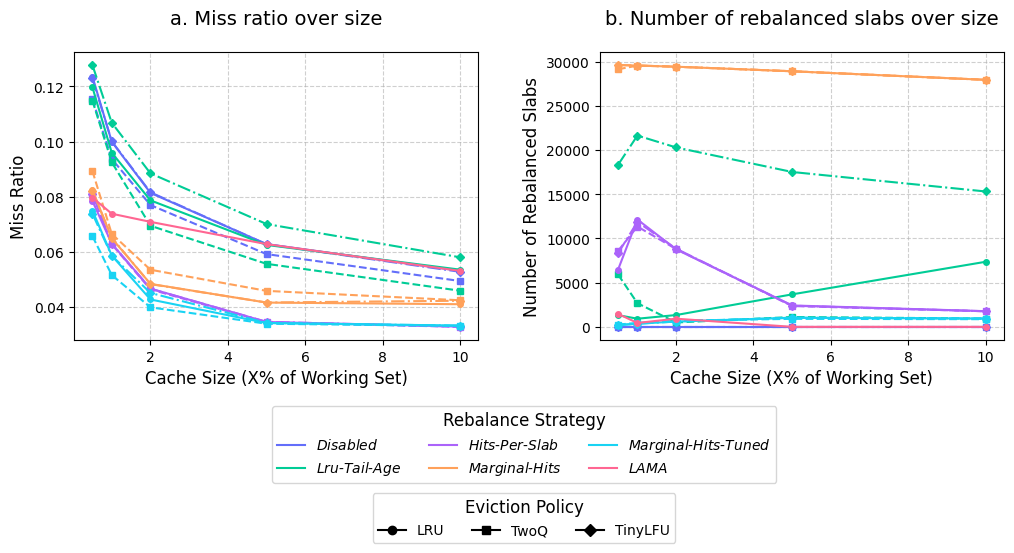

In [131]:
plot_trace_wsr_line_publish_quality(df, "meta_202210_kv", y1="miss_ratio", y2="rebalanced_slabs", 
                                    output_pdf="../../../figures/meta_202210_kv_details.pdf", dpi=300)

In [44]:
df[(df['trace_name'] == 'meta_202210_kv') & (df['rebalance_strategy'] == 'lama')][['wsr', 'rebalanced_slabs', 'n_rebalanced_slabs']]

,wsr,rebalanced_slabs,n_rebalanced_slabs
6,0.005,1467.0,1274
25,0.010,441.0,53
44,0.020,922.0,27
63,0.050,0.0,0
82,0.100,0.0,0


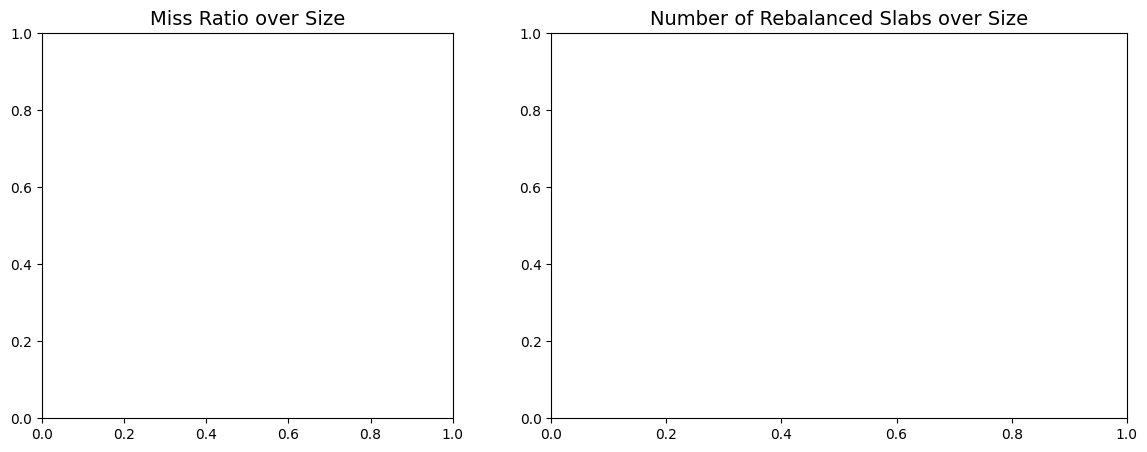

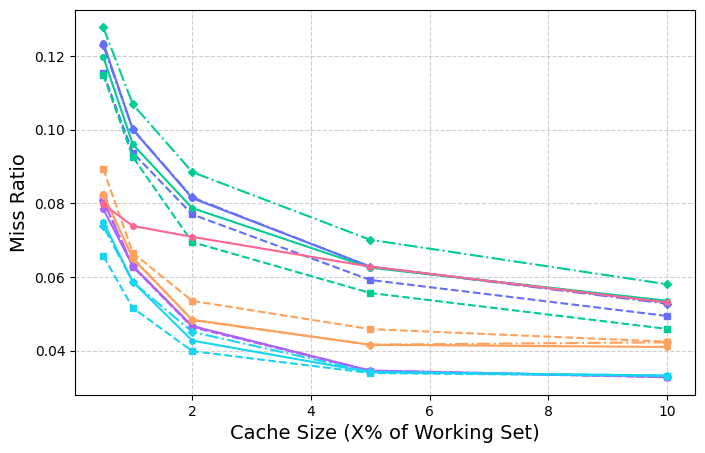

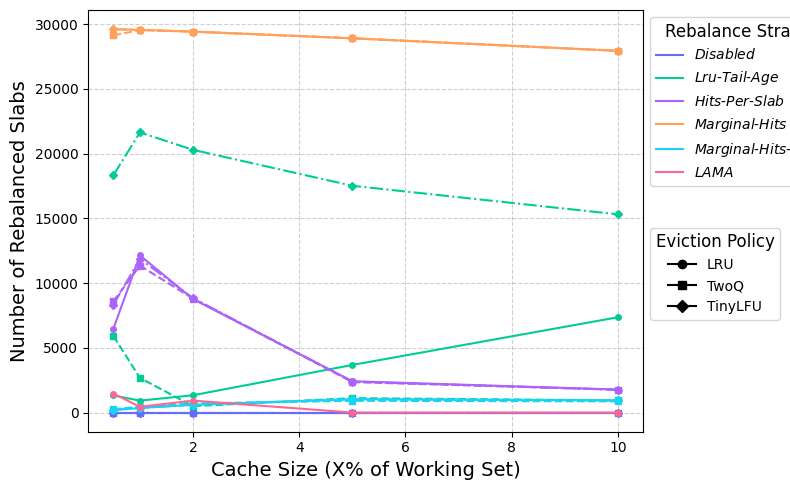

In [80]:
import matplotlib.pyplot as plt

# Create subplots with adjusted widths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.4]})

# Plot the first figure (Miss Ratio over Size)
plot_df_a = df[df['rebalance_strategy'] != 'free-mem']
plot_trace_wsr_line_publish_quality(
    plot_df_a,
    "meta_202210_kv",
    y="miss_ratio",
    show_legend=False
)
ax1.set_title("Miss Ratio over Size", fontsize=14)

# Plot the second figure (Number of Rebalanced Slabs over Size)
plot_df_b = df[df['rebalance_strategy'] != 'free-mem']
plot_trace_wsr_line_publish_quality(
    plot_df_b,
    "meta_202210_kv",
    y="rebalanced_slabs",
    show_legend=True
)
ax2.set_title("Number of Rebalanced Slabs over Size", fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
plot_trace_wsr_line_publish_quality(df, "twitter_cluster11", 0.01, x="allocator", y="miss_ratio", color="rebalance_strategy")

No data for trace_name=twitter_cluster11 and wsr=0.01


In [13]:
df['trace_name'].unique()

array(['meta_202210_kv', 'meta_202401_kv', 'twitter_cluster17',
       'twitter_cluster18', 'twitter_cluster24', 'twitter_cluster29',
       'twitter_cluster44', 'twitter_cluster45', 'twitter_cluster49',
       'twitter_cluster50', 'twitter_cluster52', 'twitter_cluster53'],
      dtype=object)

In [9]:
import plotly.express as px

def plot_boxplot_distribution(
    df,
    x="allocator",
    y="miss_ratio",
    color="rebalance_strategy",
    title="Miss Ratio by Allocator and Rebalance Strategy"
):
    # Only keep selected strategies and set categorical order
    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned-aimd"
    ]
    plot_df = df[df[color].isin(selected_strategies)].copy()
    plot_df[color] = pd.Categorical(plot_df[color], categories=selected_strategies, ordered=True)

    fig = px.box(
        plot_df,
        x=x,
        y=y,
        color=color,
        title=title,
        category_orders={x: sorted(plot_df[x].unique()), color: selected_strategies}
    )
    fig.update_layout(
        boxmode='group',
        xaxis_title=x,
        yaxis_title=y,
        legend_title=color
    )
    fig.show()

In [10]:
import plotly.express as px

def plot_barplot_distribution_by_trace(
    df,
    trace_name,
    x="allocator",
    y="miss_ratio",
    color="rebalance_strategy",
    title=None
):
    # Filter by trace_name
    plot_df = df[df["trace_name"] == trace_name].copy()
    if plot_df.empty:
        print(f"No data for trace_name: {trace_name}")
        return

    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned-aimd"
    ]
    plot_df = plot_df[plot_df[color].isin(selected_strategies)].copy()
    plot_df[color] = pd.Categorical(plot_df[color], categories=selected_strategies, ordered=True)

    if title is None:
        title = f"Miss Ratio by Allocator and Rebalance Strategy for {trace_name}"

    fig = px.bar(
        plot_df,
        x=x,
        y=y,
        color=color,
        barmode="group",
        title=title,
        category_orders={x: sorted(plot_df[x].unique()), color: selected_strategies}
    )
    fig.update_layout(
        xaxis_title=x,
        yaxis_title=y,
        legend_title=color
    )
    fig.show()

In [11]:
import plotly.express as px

def plot_lru2q_marginal_boxplot(df):
    # Filter for allocator == 'LRU2Q' and rebalance_strategy is exactly 'marginal-hits' or 'marginal-hits-tuned-aimd'
    mask = (
        (df["allocator"] == "LRU2Q") &
        (df["rebalance_strategy"].isin(["marginal-hits", "marginal-hits-tuned-aimd"]))
    )
    plot_df = df[mask].copy()
    plot_df["rebalance_strategy"] = pd.Categorical(
        plot_df["rebalance_strategy"],
        categories=["marginal-hits", "marginal-hits-tuned-aimd"],
        ordered=True
    )

    fig = px.box(
        plot_df,
        x="rebalance_strategy",
        y="miss_ratio_reduction_from_disabled",
        color="tag",
        title="LRU2Q: Miss Ratio Reduction from Disabled (cold vs warm-cold)",
    )
    fig.update_layout(
        boxmode='group',
        xaxis_title="Rebalance Strategy",
        yaxis_title="Miss Ratio",
        legend_title="Tag"
    )
    fig.show()

In [12]:
import plotly.express as px

def plot_tuned_improvement_by_allocator(df):
    # Only keep rows with non-null tuned_improvement
    plot_df = df[df["tuned_improvement"].notnull()].copy()
    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned-aimd"
    ]
    plot_df = plot_df[plot_df['rebalance_strategy'].isin(selected_strategies)].copy()
    if plot_df.empty:
        print("No data with tuned_improvement.")
        return

    fig = px.box(
        plot_df,
        x="allocator",
        y="tuned_improvement",
        title="Tuned Improvement by Allocator"
    )
    fig.update_layout(
        xaxis_title="Allocator",
        yaxis_title="Tuned Improvement (miss ratio reduction)",
        boxmode='group'
    )
    fig.show()

In [13]:
import plotly.express as px

def plot_near_min_miss_ratio_pie(df, threshold=0.001):
    # Find min miss_ratio for each trace_name
    min_miss = df.groupby("trace_name")["miss_ratio"].min().reset_index()
    min_miss = min_miss.rename(columns={"miss_ratio": "min_miss_ratio"})

    # Merge min_miss_ratio into df
    merged = df.merge(min_miss, on="trace_name", how="left")
    # Keep rows within threshold of min for each trace_name
    near_min = merged[merged["miss_ratio"] <= merged["min_miss_ratio"] + threshold].copy()
    if near_min.empty:
        print("No near-min rows found.")
        return

    # Add a combined column for allocator + rebalance_strategy
    near_min["allocator_rebalance_strategy"] = near_min["allocator"] + "_" + near_min["rebalance_strategy"]

    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned-aimd"
    ]

    # Helper to plot pie chart for a column
    def plot_pie(group_col, title, category_order=None):
        counts = near_min[group_col].value_counts(normalize=True).reset_index()
        counts.columns = [group_col, "percent"]
        counts["percent"] = counts["percent"] * 100

        if category_order is not None:
            # Ensure all categories are present and in order
            for cat in category_order:
                if cat not in counts[group_col].values:
                    counts = counts.append({group_col: cat, "percent": 0}, ignore_index=True)
            counts[group_col] = pd.Categorical(counts[group_col], categories=category_order, ordered=True)
            counts = counts.sort_values(group_col)

        fig = px.pie(
            counts,
            names=group_col,
            values="percent",
            title=title,
            hole=0.3,
            category_orders={group_col: category_order} if category_order else None
        )
        fig.update_traces(textinfo='percent+label')
        fig.show()

    plot_pie("allocator", "Share of Allocator in Near-Min Miss Ratio (all traces)")
    plot_pie(
        "rebalance_strategy",
        "Share of Rebalance Strategy in Near-Min Miss Ratio (all traces)",
        category_order=selected_strategies
    )
    plot_pie("allocator_rebalance_strategy", "Share of Allocator+Rebalance Strategy in Near-Min Miss Ratio (all traces)")

In [60]:
remapped_df['monitor_interval'].unique()

array([100000,  50000,   1000])

In [33]:
plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_df = plot_df[(plot_df['tag'].isna()) | (plot_df['tag'] == 'cold')]
plot_boxplot_distribution(plot_df, y="miss_ratio_reduction_from_disabled")

In [29]:
find_min_row(plot_df[plot_df['allocator'] == 'TINYLFU'], 'miss_ratio_reduction_from_disabled')

trace_name                                                            twitter_cluster26
number_of_requests                                                            156594627
wsr                                                                                0.05
slab_size                                                                             1
slab_cnt                                                                            106
rebalance_strategy                                             marginal-hits-tuned-aimd
allocator                                                                       TINYLFU
tag                                                                                None
miss_ratio                                                                     0.135427
n_rebalanced_slabs                                                                   80
monitor_interval                                                                 100000
n_alloc_failures                

In [32]:
# 3 and 41
# 42 hits-per-slab is the best

plot_df = remapped_df[(remapped_df['monitor_interval'] == 100_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_df = plot_df[(plot_df['tag'].isna()) | (plot_df['tag'] == 'warm-cold')]
plot_barplot_distribution_by_trace(plot_df, 'twitter_cluster41')

In [176]:
plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_lru2q_marginal_boxplot(plot_df)

In [117]:
plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_df = plot_df[(plot_df['tag'].isna()) | (plot_df['tag'] == 'warm-cold')]
plot_tuned_improvement_by_allocator(plot_df)

In [112]:
find_min_row(plot_df[plot_df['allocator'] == 'TINYLFU'], 'tuned_improvement')

trace_name                                                             twitter_cluster8
number_of_requests                                                           1302137879
wsr                                                                                0.05
slab_size                                                                             1
slab_cnt                                                                             53
rebalance_strategy                                             marginal-hits-tuned-mimd
allocator                                                                       TINYLFU
tag                                                                                None
miss_ratio                                                                     0.632363
n_rebalanced_slabs                                                                   72
monitor_interval                                                                  50000
n_alloc_failures                

In [156]:
plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_df = plot_df[(plot_df['tag'].isna()) | (plot_df['tag'] == 'warm-cold')]
selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned-aimd"
    ]
plot_df = plot_df[plot_df['rebalance_strategy'].isin(selected_strategies)].copy()
plot_near_min_miss_ratio_pie(plot_df[plot_df['allocator']=='LRU'])

In [180]:
import pandas as pd
import plotly.express as px

# Create DataFrame from your CSV-like string
from io import StringIO

data = """
allocator,rebalance_strategy,throughput,rebalancer_cpu_cycle,request_serving_cpu_cycle,hit_ratio,n_rebalanced_slabs
SIMPLE2Q,marginal-hits,633026.441145437,185966672177,3639047183825,0.9313,23434
SIMPLE2Q,marginal-hits,630812.2251369195,188943458488,3673172292220,0.9311,23434
SIMPLE2Q,marginal-hits,628402.9596030737,183137736021,3657291991953,0.9317,23434
SIMPLE2Q,marginal-hits-tuned,598742.4360827137,22732501836,3868801441517,0.9369,735
SIMPLE2Q,marginal-hits-tuned,607819.9610586013,21878553011,3827640704141,0.9362,666
SIMPLE2Q,marginal-hits-tuned,615984.9047524764,22532308253,3777494512006,0.9365,678
"""

df = pd.read_csv(StringIO(data))

# Compute new columns
df["miss_ratio"] = 1 - df["hit_ratio"]
df["rebalancer_cpu_cycle_percent"] = df["rebalancer_cpu_cycle"] / df["request_serving_cpu_cycle"]

# Group by rebalance_strategy and compute mean and std for each metric
agg = df.groupby("rebalance_strategy").agg(
    throughput_mean=("throughput", "mean"),
    throughput_std=("throughput", "std"),
    rebalancer_cpu_cycle_mean=("rebalancer_cpu_cycle", "mean"),
    rebalancer_cpu_cycle_std=("rebalancer_cpu_cycle", "std"),
    request_serving_cpu_cycle_mean=("request_serving_cpu_cycle", "mean"),
    request_serving_cpu_cycle_std=("request_serving_cpu_cycle", "std"),
    miss_ratio_mean=("miss_ratio", "mean"),
    miss_ratio_std=("miss_ratio", "std"),
    rebalancer_cpu_cycle_percent_mean=("rebalancer_cpu_cycle_percent", "mean"),
    rebalancer_cpu_cycle_percent_std=("rebalancer_cpu_cycle_percent", "std"),
    n_rebalanced_slabs_mean=("n_rebalanced_slabs", "mean"),
    n_rebalanced_slabs_std=("n_rebalanced_slabs", "std"),
).reset_index()

# Show tables for each metric
metrics = [
    ("throughput", "throughput_mean", "throughput_std"),
    ("rebalancer_cpu_cycle", "rebalancer_cpu_cycle_mean", "rebalancer_cpu_cycle_std"),
    ("request_serving_cpu_cycle", "request_serving_cpu_cycle_mean", "request_serving_cpu_cycle_std"),
    ("miss_ratio", "miss_ratio_mean", "miss_ratio_std"),
    ("rebalancer_cpu_cycle_percent", "rebalancer_cpu_cycle_percent_mean", "rebalancer_cpu_cycle_percent_std"),
    ("n_rebalanced_slabs", "n_rebalanced_slabs_mean", "n_rebalanced_slabs_std"),
]

# Show tables for each metric, rounded to two digits
# Show tables for each metric, rounded to two digits (except percent: 6 digits)
for metric, mean_col, std_col in metrics:
    table = agg[["rebalance_strategy", mean_col, std_col]].rename(
        columns={mean_col: "mean", std_col: "std"}
    ).copy()
    if metric == "rebalancer_cpu_cycle_percent":
        table["mean"] = table["mean"].round(6)
        table["std"] = table["std"].round(6)
    else:
        table["mean"] = table["mean"].round(2)
        table["std"] = table["std"].round(2)
    print(f"\n{metric} (mean ± std):")
    print(table.to_string(index=False))


throughput (mean ± std):
 rebalance_strategy      mean     std
      marginal-hits 630747.21 2312.43
marginal-hits-tuned 607515.77 8625.26

rebalancer_cpu_cycle (mean ± std):
 rebalance_strategy         mean          std
      marginal-hits 1.860160e+11 2.903175e+09
marginal-hits-tuned 2.238112e+10 4.465986e+08

request_serving_cpu_cycle (mean ± std):
 rebalance_strategy         mean          std
      marginal-hits 3.656504e+12 1.707620e+10
marginal-hits-tuned 3.824646e+12 4.572709e+10

miss_ratio (mean ± std):
 rebalance_strategy  mean  std
      marginal-hits  0.07  0.0
marginal-hits-tuned  0.06  0.0

rebalancer_cpu_cycle_percent (mean ± std):
 rebalance_strategy     mean      std
      marginal-hits 0.050872 0.000711
marginal-hits-tuned 0.005852 0.000126

n_rebalanced_slabs (mean ± std):
 rebalance_strategy    mean   std
      marginal-hits 23434.0  0.00
marginal-hits-tuned   693.0 36.86


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_box_modern_matplotlib(
    df, wsr, y="miss_ratio", x="allocator", color="rebalance_strategy", tag_col="tag"
):
    plot_df = df[df["wsr"] == wsr].copy()
    if plot_df.empty:
        print("No data for this filter.")
        return

    rebalance_order = [
        "disabled", "free-mem", "tail-age", "hits", "marginal-hits", "marginal-hits-tuned"
    ]
    tag_order = ["warm-cold", "cold"]

    plot_df[color] = pd.Categorical(plot_df[color], categories=rebalance_order, ordered=True)
    if tag_col in plot_df.columns:
        plot_df[tag_col] = plot_df[tag_col].astype("object").fillna("")
        plot_df[tag_col] = pd.Categorical(plot_df[tag_col], categories=[""] + tag_order, ordered=True)

    plot_df = plot_df.sort_values([x, color, tag_col])

    allocators = plot_df[x].unique()
    n_alloc = len(allocators)

    plotly_palette = [
        "#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A", "#19D3F3",
        "#FF6692", "#B6E880", "#FF97FF", "#FECB52"
    ]
    color_map = {k: plotly_palette[i % len(plotly_palette)] for i, k in enumerate(rebalance_order)}
    hatch_map = {"warm-cold": "xx", "cold": "//", "": ""}

    fig, ax = plt.subplots(figsize=(7, 3.5))
    width = 0.8

    for i, alloc in enumerate(allocators):
        group = plot_df[plot_df[x] == alloc]
        group = group.sort_values([color, tag_col])
        combos = group.groupby([color, tag_col])
        n = len(combos)
        for j, ((reb, tag), sub) in enumerate(combos):
            pos = i - width/2 + width*(j+0.5)/n if n > 1 else i
            # Draw boxplot manually for this group
            data = sub[y].dropna().values
            if len(data) == 0:
                continue
            box = ax.boxplot(
                [data],
                positions=[pos],
                widths=width/n if n > 1 else width*0.95,
                patch_artist=True,
                boxprops=dict(
                    facecolor=color_map.get(reb, "#cccccc"),
                    hatch=hatch_map.get(tag, ""),
                    edgecolor="black"
                ),
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(markerfacecolor=color_map.get(reb, "#cccccc"), marker='o', markersize=3, linestyle='none', alpha=0.5)
            )

    ax.set_xticks(range(n_alloc))
    ax.set_xticklabels(allocators)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} boxplot for wsr={wsr}")

    # Combined legend for color and pattern
    legend_items = []
    for reb in rebalance_order:
        for tag in tag_order:
            if ((plot_df[color] == reb) & (plot_df[tag_col] == tag)).any():
                legend_items.append(
                    Patch(
                        facecolor=color_map[reb],
                        edgecolor='black',
                        label=f"{reb} | {tag}",
                        hatch=hatch_map[tag]
                    )
                )
    for reb in rebalance_order:
        if ((plot_df[color] == reb) & (plot_df[tag_col] == "")).any():
            legend_items.append(
                Patch(
                    facecolor=color_map[reb],
                    edgecolor='black',
                    label=f"{reb}",
                    hatch=""
                )
            )

    ax.legend(
        handles=legend_items,
        title=f"{color} | tag",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=True
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    plt.show()

NameError: name 'remapped_df' is not defined

/tmp/ipykernel_2830983/1905032661.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combos = group.groupby([color, tag_col])
/tmp/ipykernel_2830983/1905032661.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combos = group.groupby([color, tag_col])
/tmp/ipykernel_2830983/1905032661.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combos = group.groupby([color, tag_col])


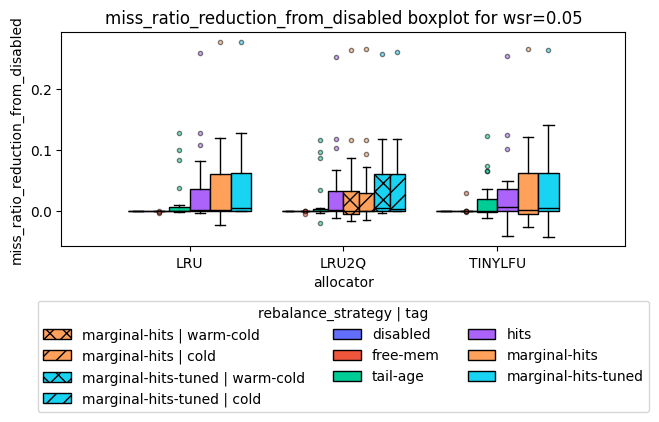

In [8]:
plot_box_modern_matplotlib(remapped_df, wsr=0.05, y="miss_ratio_reduction_from_disabled", x="allocator", color="rebalance_strategy", tag_col="tag")

In [130]:
remapped_df[remapped_df['miss_ratio_reduction_from_disabled'] < -0.001]

,trace_name,number_of_requests,wsr,slab_size,slab_cnt,rebalance_strategy,allocator,tag,miss_ratio,n_rebalanced_slabs,monitor_interval,n_alloc_failures,uuid,miss_ratio_reduction_from_disabled
250,meta_202210_kv,1482478166,0.05,4,1097,tail-age,TINYLFU,None,0.067171,12512,100000,0,meta_202210_kv-53e3c75b8d7baf119a82e420dc6b18ab,-0.004408
96,meta_202401_kv,1191241025,0.05,4,583,tail-age,LRU2Q,None,0.096949,219,100000,0,meta_202401_kv-ce9043d488b94ae6efa188fefcb9a7b5,-0.004626
233,meta_202401_kv,1191241025,0.05,4,583,tail-age,TINYLFU,None,0.100101,9326,100000,0,meta_202401_kv-5ce8c2457584eaf75122155dcd66079d,-0.003809
15,twitter_cluster20,3663259123,0.05,1,535,marginal-hits,LRU,None,0.055902,35228,100000,2,twitter_cluster20-95e517e3d49c5c3910c304a74d4e...,-0.002159
144,twitter_cluster20,3663259123,0.05,1,535,marginal-hits,LRU2Q,warm-cold,0.056239,34152,100000,4,twitter_cluster20-3a37c69db350f1237605af01cbb1...,-0.007180
282,twitter_cluster20,3663259123,0.05,1,535,marginal-hits,LRU2Q,cold,0.055830,35197,100000,2,twitter_cluster20-9a3ba0f02403c3ec9d6362feaac5...,-0.006771
141,twitter_cluster20,3663259123,0.05,1,535,marginal-hits,TINYLFU,None,0.055734,35226,100000,2,twitter_cluster20-075894d3ba1f683bedff40df5503...,-0.003288
207,twitter_cluster20,3663259123,0.05,1,535,tail-age,TINYLFU,None,0.053460,5638,100000,9,twitter_cluster20-08e9ec8693b6baa6bbf5af764318...,-0.001015
270,twitter_cluster22,2030691718,0.05,1,2077,marginal-hits,LRU,None,0.281170,12218,100000,0,twitter_cluster22-3f1cb3f560366bc2c3e953bebb32...,-0.002576
177,twitter_cluster22,2030691718,0.05,1,2077,marginal-hits,LRU2Q,cold,0.271674,12608,100000,0,twitter_cluster22-4c3afd71cac8ad8b7d9ac3339250...,-0.009204


In [ ]:
"""
write a function process this df
group by trace_name, wsr, and allocator
for each group use the rwo whose rebalance_strategy = 'disabled' as the baseline
then for each row's miss ratio minus the baseline's miss ratio
compute a new columns miss ratio reduction from disabled
"""

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_bar_modern_matplotlib(
    df, trace_name, wsr, y="miss_ratio", x="allocator", color="rebalance_strategy", tag_col="tag"
):
    # Filter
    plot_df = df[(df["trace_name"] == trace_name) & (df["wsr"] == wsr)].copy()
    if plot_df.empty:
        print("No data for this filter.")
        return

    # Consistent order
    rebalance_order = [
        "disabled", "free-mem", "tail-age", "hits", "marginal-hits", "marginal-hits-tuned"
    ]
    tag_order = ["warm-cold", "cold"]

    # Set categorical types for correct sorting
    plot_df[color] = pd.Categorical(plot_df[color], categories=rebalance_order, ordered=True)
    if tag_col in plot_df.columns:
        plot_df[tag_col] = plot_df[tag_col].astype("object").fillna("")
        plot_df[tag_col] = pd.Categorical(plot_df[tag_col], categories=[""] + tag_order, ordered=True)

    # Sort for consistent plotting
    plot_df = plot_df.sort_values([x, color, tag_col])

    # Prepare bar positions
    allocators = plot_df[x].unique()
    n_alloc = len(allocators)
    bar_data = []
    for alloc in allocators:
        group = plot_df[plot_df[x] == alloc]
        for _, row in group.iterrows():
            bar_data.append((alloc, row[color], row[tag_col], row[y]))

    # Use Plotly color palette
    plotly_palette = [
        "#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A", "#19D3F3",
        "#FF6692", "#B6E880", "#FF97FF", "#FECB52"
    ]
    color_map = {k: plotly_palette[i % len(plotly_palette)] for i, k in enumerate(rebalance_order)}
    hatch_map = {"warm-cold": "xx", "cold": "//", "": ""}

    # Calculate bar positions
    fig, ax = plt.subplots(figsize=(7, 3.5))
    width = 0.8
    for i, alloc in enumerate(allocators):
        group = [b for b in bar_data if b[0] == alloc]
        n = len(group)
        for j, (alloc, reb, tag, val) in enumerate(group):
            pos = i - width/2 + width*(j+0.5)/n if n > 1 else i
            ax.bar(
                pos, val, width=width/n if n > 1 else width*0.95,
                color=color_map.get(reb, "#cccccc"),
                label=None,
                hatch=hatch_map.get(tag, ""),
                edgecolor="black"
            )

    # Set x-ticks and labels
    ax.set_xticks(range(n_alloc))
    ax.set_xticklabels(allocators)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} for {trace_name} (wsr={wsr})")

    # Combined legend for color and pattern
    legend_items = []
    for reb in rebalance_order:
        for tag in tag_order:
            if ((plot_df[color] == reb) & (plot_df[tag_col] == tag)).any():
                legend_items.append(
                    Patch(
                        facecolor=color_map[reb],
                        edgecolor='black',
                        label=f"{reb} | {tag}",
                        hatch=hatch_map[tag]
                    )
                )
    # Add legend for bars without tag if present
    for reb in rebalance_order:
        if ((plot_df[color] == reb) & (plot_df[tag_col] == "")).any():
            legend_items.append(
                Patch(
                    facecolor=color_map[reb],
                    edgecolor='black',
                    label=f"{reb}",
                    hatch=""
                )
            )

    ax.legend(
        handles=legend_items,
        title=f"{color} | tag",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=True
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    plt.show()

In [83]:
remapped_df['trace_name'].unique()

array(['twitter_cluster19', 'twitter_cluster49', 'twitter_cluster22',
       'twitter_cluster3', 'meta_202401_kv', 'twitter_cluster21',
       'twitter_cluster53', 'twitter_cluster10', 'twitter_cluster26',
       'twitter_cluster20', 'twitter_cluster45', 'twitter_cluster48',
       'twitter_cluster8', 'twitter_cluster50', 'twitter_cluster30',
       'twitter_cluster7', 'twitter_cluster35', 'meta_202210_kv'],
      dtype=object)

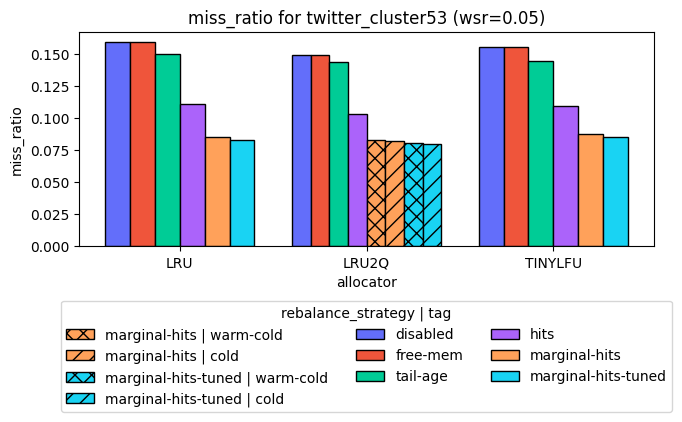

In [173]:
plot_bar_modern_matplotlib(remapped_df, "twitter_cluster53", 0.05)

In [ ]:
"""
process df for the rows whose rebalance_strategy is marginal-hits-tuned
use it's trace_name, wsr, allocator, tag to find the row with the same value and rebalance_strategy = marginal-hits

compute miss ratio of marginal-hits-tuned - the miss ratio of this found row, this diff will be added to a new column 
tuned_improvement
remember only rows whose rebalance_strategy is marginal-hits-tuned will have this new col
"""

In [ ]:
stats[(stats['trace_name'] == 'meta_202210_kv')].sort_values(by = "_missRatio")
"""
help me write a function, remap the df
rule:
1) rebalanceStrategy == marginal-hits-new -> rebalance_strategy = 'marginal-hits-tuned'
2) rebalanceStrategy == marginal-hits-old -> rebalance_strategy = 'marginal-hits'
other rebalanceStrategy values should be kept as is

allocator 
if TINYLFUTail -> allocator = 'TINYLFU'
if SIMPLE2Q -> allocator = LRU

tag:
if rebalanceStrategy == marginal-hits-new or rebalanceStrategy == marginal-hits-old and allocator = LRU2Q
if countColdTailHitsOnly == True -> tag = 'cold-tail' else tag 'warm-cold-tail'

_missRatio rename to miss_ratio
_rebalancerNumRebalancedSlabs rename to n_rebalanced_slabs
wakeUpRebalancerEveryXReqs rename to monitor_interval
_allocFailures rename to n_alloc_failures


other columns to keep trace_name, number_of_requests, wsr, slab_size, slab_cnt
"""

,trace_name,rebalanceStrategy,allocator,_missRatio,_rebalancerNumRebalancedSlabs,countColdTailHitsOnly,wakeUpRebalancerEveryXReqs
48,meta_202210_kv,marginal-hits-new,LRU2Q,0.034166,1626,True,100000
52,meta_202210_kv,marginal-hits-new,SIMPLE2Q,0.034222,1634,NaN,100000
10,meta_202210_kv,marginal-hits-new,TINYLFUTail,0.034270,1673,NaN,100000
32,meta_202210_kv,marginal-hits-new,LRU2Q,0.034311,2210,NaN,100000
54,meta_202210_kv,hits,LRU2Q,0.034472,2243,NaN,100000
14,meta_202210_kv,hits,SIMPLE2Q,0.034596,2257,NaN,100000
39,meta_202210_kv,hits,TINYLFU,0.034639,2234,NaN,100000
37,meta_202210_kv,marginal-hits-old,SIMPLE2Q,0.036264,14454,NaN,100000
12,meta_202210_kv,marginal-hits-old,TINYLFUTail,0.036340,14454,NaN,100000
6,meta_202210_kv,marginal-hits-old,LRU2Q,0.036966,14454,NaN,100000
